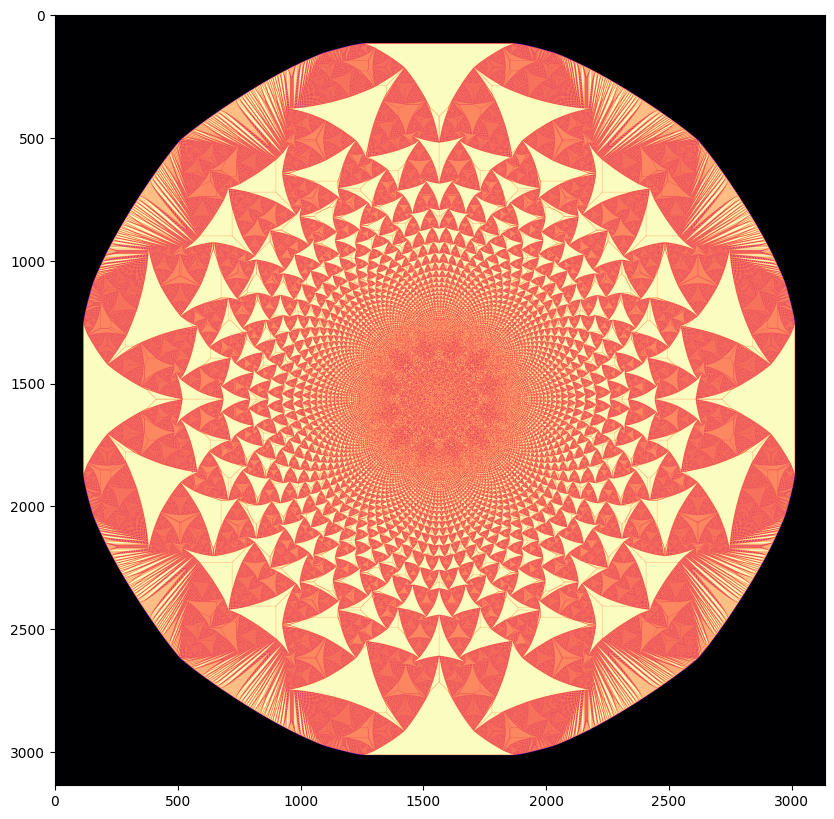

number of frames: 22
total number of grains: 16000000 expected 16000000
frame size: (3136, 3136)


In [146]:
import zarr
import matplotlib.pyplot as plt
import numpy as np

# Saved from earlier run:
# data = zarr.open('../sandpile_data/infinite_grid_data/v0_data.zarr', mode='r')

grains = 16000000
data = zarr.open(f'../sandpile_data/infinite_grid_data/data{grains}.zarr', mode='r')
last_frame = data['history'][-1] # Grabs the last saved state
to_display = np.minimum(last_frame, 5)

plt.figure(figsize=(12, 10))
plt.imshow(to_display, cmap='magma')
plt.show()
print('number of frames:', len(data['history']))
print('total number of grains:', np.sum(last_frame), 'expected', grains)
print('frame size:', last_frame.shape)

In [152]:
from PIL import Image

def save_high_res_png(grid_np, filename):
    n = grid_np.shape[0]

    # 1. Create an empty RGB image array (Height, Width, 3)
    img_array = np.zeros((n, n, 3), dtype=np.uint8)

    # 2. Define your color palette (scaled to 0-255 for PNG)
    # Mapping based on your 'update_colors' logic
    colors = {
        0: [13, 13, 26],    # Dark Blue
        1: [77, 0, 128],    # Indigo
        3: [0, 204, 204],   # Cyan
        2: [255, 0, 153],   # Pink
        'plus': [255, 0, 0] # Red (for cells >= 4)
    }

    # 3. Fill the image array based on grid values
    img_array[grid_np == 0] = colors[0]
    img_array[grid_np == 1] = colors[1]
    img_array[grid_np == 2] = colors[2]
    img_array[grid_np == 3] = colors[3]
    img_array[grid_np >= 4] = colors['plus']

    # 4. Save using Pillow
    img = Image.fromarray(img_array, 'RGB')
    img.save(filename)
    print(f"High-res image saved to {filename} ({n}x{n} pixels)")

dir = f'/Users/alan/Python/sandpile_data/infinite_grid_data/sandpile_final{grains}.png'
save_high_res_png(last_frame, dir)

High-res image saved to /Users/alan/Python/sandpile_data/infinite_grid_data/sandpile_final16000000.png (3136x3136 pixels)


/var/folders/vp/dyd86hcn1lv_5_3fbzpgff040000gn/T/ipykernel_88907/3263692161.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, 'RGB')


In [147]:
center = 600
k = 2
print(last_frame[center-k:center+k, center-k:center+k])

print(np.max(last_frame))
last_frame.shape

[[0 3 2 0]
 [3 2 3 3]
 [2 3 0 3]
 [0 3 3 2]]
3


(3136, 3136)

## Timing info:
-- A lot of time gets spent adding grains. putting the right number to begin with saves a ton of time.
-- Rapid spread with more initial grains makes more grains take a lot longer
-- Total timing is somewhat unpredictable but steps to stabilization seems to be proportional to num grains

### 500k grains: 6 sec (no expansion at all, unreliable datapoint), 101 steps

### 1M grains: 12 sec (also no expansion at all), 194 steps

### 2M grains: 44 sec, 370 steps
boundary at 801 hit on step 77

### 4M grains, 741 steps
init 601, expand 20% -- 240 sec
init 801, expand 10% -- 233 sec
frame dim 1557

### 8M grains, 1424 steps
init 801, expand 10% -- 876 sec
boundary at 801 hit on step 39
boundary at 1001 hit on step 73
frame dim 2278

### 16M grains, 2815 steps
init 1001, expand 10%
boundary at 1001 hit on step 58
expect: 3000 steps, 3500 sec, frame dim 3200
actual: 2815 steps, 3500sec, frame dim 3136

### 32M grains ?
init 1001, expand 100
expect: 6k steps, 7k sec, frame dim 4500


In [140]:
876*4*4*4/(60*60)
3200 * 1.4
140/115

1.2173913043478262